# Exercice 7 - Application of unsupervised learning

Dataset choisi: **Steam Games Dataset**.

Source: Kaggle, https://www.kaggle.com/datasets/fronkongames/steam-games-dataset

Le CSV est charge depuis `dataset/steam_game_dataset.csv` (ou `reponse/data/steam_games.csv`). Le fichier complet fait environ 400 Mo; seules les colonnes utiles au clustering sont chargees (`Name`, `Price`, `Positive`, `Negative`, `Genres`).

## Objectif

Le but est d'identifier des profils de jeux Steam sans utiliser de variable cible. On cherche par exemple des groupes correspondant a des jeux gratuits populaires, des jeux payants bien recus, des jeux de niche avec peu d'avis, ou des jeux chers avec reception faible.

Variables construites: `total_reviews`, `positive_ratio`, `log_total_reviews`, `is_free`, encodage multi-hot des genres. On applique `log1p` aux volumes d'avis pour eviter que quelques jeux tres populaires dominent tout le clustering.

In [1]:
import csv
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

DATA_PATH_CANDIDATES = [
    Path('reponse/data/steam_games.csv'),
    Path('../data/steam_games.csv'),
    Path('../../reponse/data/steam_games.csv'),
    Path('dataset/steam_game_dataset.csv'),
    Path('../dataset/steam_game_dataset.csv'),
    Path('../../dataset/steam_game_dataset.csv'),
]
DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), DATA_PATH_CANDIDATES[0])
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset absent: {DATA_PATH}. Telechargez le CSV Kaggle puis modifiez DATA_PATH si besoin."
    )

# Defaut de l'export CSV: l'en-tete contient 'DiscountDLC count' (fusion de
# 'Discount' et 'DLC count'), soit 39 noms pour 40 champs de donnees. Sans
# reparation, pandas decale toutes les colonnes d'un cran. On repare l'en-tete
# puis on ne charge que les colonnes utiles au clustering (le fichier complet
# fait ~400 Mo avec descriptions, urls, tags...).
with open(DATA_PATH, encoding='utf-8') as f:
    header = next(csv.reader(f))
fixed_header = []
for h in header:
    if h == 'DiscountDLC count':
        fixed_header += ['Discount', 'DLC count']
    else:
        fixed_header.append(h)

USECOLS = {'name', 'price', 'positive', 'negative', 'genres'}
df = pd.read_csv(
    DATA_PATH,
    names=fixed_header,
    skiprows=1,
    usecols=[c for c in fixed_header if c.strip().lower() in USECOLS],
)
df.columns = [c.strip().lower() for c in df.columns]
print(df.shape)
df.head()

(125855, 5)


,name,price,positive,negative,genres
0,Black Dragon Mage Playtest,0.00,0,0,NaN
1,Supipara - Chapter 1 Spring Has Come!,5.24,252,3,Adventure
2,Mystery Solitaire The Black Raven,4.99,21,3,Casual
3,버튜버 파라노이아 - Vtuber Paranoia,8.99,0,0,"Casual,Indie,Simulation"
4,Maze Quest VR,4.99,0,0,"Action,Early Access"


In [2]:
for col in ['price', 'positive', 'negative']:
    if col not in df.columns:
        raise ValueError(f"Colonne attendue absente: {col}")
    df[col] = pd.to_numeric(df[col], errors='coerce')

work = df.dropna(subset=['price', 'positive', 'negative']).copy()
work['total_reviews'] = work['positive'] + work['negative']
work = work[work['total_reviews'] > 0].copy()
work['positive_ratio'] = work['positive'] / work['total_reviews']
work['log_total_reviews'] = np.log1p(work['total_reviews'])
work['log_positive'] = np.log1p(work['positive'])
work['log_negative'] = np.log1p(work['negative'])
work['is_free'] = (work['price'] == 0).astype(int)

numeric_features = ['price', 'is_free', 'positive_ratio', 'log_total_reviews', 'log_positive', 'log_negative']
X_num = work[numeric_features].copy()

if 'genres' in work.columns:
    # les genres sont separes par des virgules dans ce CSV (';' dans d'autres versions)
    genre_lists = work['genres'].fillna('').astype(str).str.replace(';', ',').str.split(',')
    genre_lists = genre_lists.apply(lambda xs: [x.strip() for x in xs if x.strip()])
    mlb = MultiLabelBinarizer()
    X_genres = pd.DataFrame(
        mlb.fit_transform(genre_lists),
        columns=[f'genre_{g}' for g in mlb.classes_],
        index=work.index,
    )
    # on ne garde que les genres presents dans au moins 1% des jeux pour eviter
    # que des dizaines de colonnes binaires rares dominent la geometrie
    keep = X_genres.columns[X_genres.mean() >= 0.01]
    X_genres = X_genres[keep]
    X_raw = pd.concat([X_num, X_genres], axis=1)
else:
    X_raw = X_num

X_scaled = StandardScaler().fit_transform(X_raw)
print('Jeux conserves (au moins 1 avis):', len(work))
print('Matrice de features:', X_scaled.shape)
print('Genres conserves:', list(X_raw.columns[len(numeric_features):]))

Jeux conserves (au moins 1 avis): 82956
Matrice de features: (82956, 18)
Genres conserves: ['genre_Action', 'genre_Adventure', 'genre_Casual', 'genre_Early Access', 'genre_Free To Play', 'genre_Indie', 'genre_Massively Multiplayer', 'genre_RPG', 'genre_Racing', 'genre_Simulation', 'genre_Sports', 'genre_Strategy']


In [3]:
# Le silhouette score est en O(n^2): on l'evalue sur un sous-echantillon de
# 10 000 jeux (sample_size), ce qui est standard pour ~100 000 observations.
summary = []
for k in range(2, 11):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled)
    summary.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels, sample_size=10_000, random_state=42),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
    })

pd.DataFrame(summary)

,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.161536,2.450384,10548.970802
1,3,0.160771,1.988915,9835.224859
2,4,0.155097,2.282464,8609.836289
3,5,0.161924,2.192028,8048.178953
4,6,0.185816,1.596438,8302.220345
5,7,0.122269,1.873373,8012.385598
6,8,0.131296,1.784101,7809.956796
7,9,0.125090,1.780112,7456.926132
8,10,0.132009,1.722760,7488.779406


In [4]:
# k = 6 est le meilleur compromis d'apres le tableau precedent: silhouette
# maximale (0.186) et Davies-Bouldin minimal (1.60) parmi k = 2..10.
k = 6
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
work['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = work.groupby('cluster').agg(
    n_games=('cluster', 'size'),
    mean_price=('price', 'mean'),
    median_price=('price', 'median'),
    mean_total_reviews=('total_reviews', 'mean'),
    median_total_reviews=('total_reviews', 'median'),
    mean_positive_ratio=('positive_ratio', 'mean'),
    free_rate=('is_free', 'mean'),
).sort_index()

print(cluster_profile.round(3))

# genres dominants et jeux les plus populaires de chaque cluster
genre_cols = [c for c in X_raw.columns if c.startswith('genre_')]
for c in sorted(work['cluster'].unique()):
    idx = work['cluster'] == c
    top_genres = X_raw.loc[idx, genre_cols].mean().sort_values(ascending=False).head(3)
    tops = ', '.join(f"{g.replace('genre_', '')} ({v:.0%})" for g, v in top_genres.items())
    examples = work.loc[idx].nlargest(3, 'total_reviews')['name'].tolist()
    print(f"cluster {c}: genres dominants: {tops}")
    print(f"           exemples (plus d'avis): {examples}")

cluster_profile

         n_games  mean_price  median_price  mean_total_reviews  \
cluster                                                          
0           6517      11.555          5.99              71.098   
1          48015       4.192          2.59              20.339   
2          19767       6.302          3.99            5301.667   
3           1705       4.613          0.99            8487.406   
4           4121       0.060          0.00            6064.921   
5           2831       6.585          2.99            1127.371   

         median_total_reviews  mean_positive_ratio  free_rate  
cluster                                                        
0                        13.0                0.718      0.054  
1                        11.0                0.755      0.049  
2                       393.0                0.790      0.044  
3                        73.0                0.639      0.425  
4                        58.0                0.774      0.984  
5                      

,n_games,mean_price,median_price,mean_total_reviews,median_total_reviews,mean_positive_ratio,free_rate
cluster,,,,,,,
0,6517,11.555326,5.99,71.097898,13.0,0.717992,0.054319
1,48015,4.192222,2.59,20.338769,11.0,0.755061,0.048922
2,19767,6.302016,3.99,5301.666565,393.0,0.790039,0.043659
3,1705,4.613290,0.99,8487.405865,73.0,0.638809,0.425220
4,4121,0.059568,0.00,6064.920650,58.0,0.774147,0.984470
5,2831,6.585359,2.99,1127.371247,19.0,0.732569,0.049452


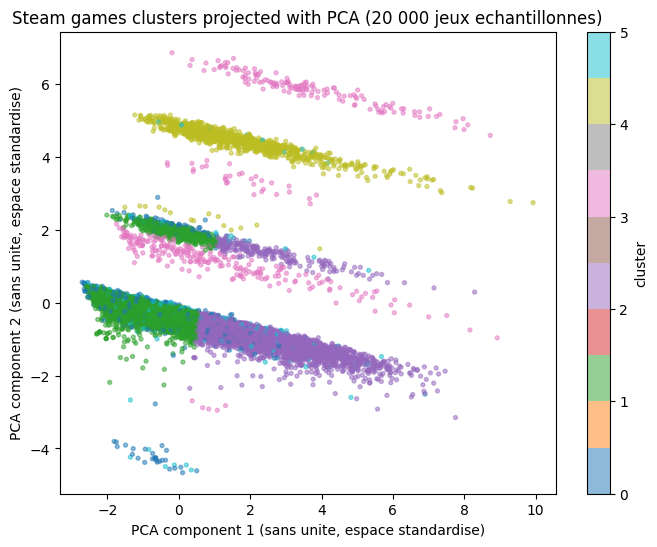

Variance expliquee: [0.1681017  0.09838107]


In [5]:
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

# sous-echantillon pour un nuage de points lisible
rng = np.random.default_rng(42)
sel = rng.choice(len(coords), size=min(20_000, len(coords)), replace=False)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[sel, 0], coords[sel, 1], c=work['cluster'].to_numpy()[sel], s=8, alpha=0.5, cmap='tab10')
plt.xlabel('PCA component 1 (sans unite, espace standardise)')
plt.ylabel('PCA component 2 (sans unite, espace standardise)')
plt.title('Steam games clusters projected with PCA (20 000 jeux echantillonnes)')
plt.colorbar(scatter, label='cluster')
plt.show()

print('Variance expliquee:', pca.explained_variance_ratio_)

## Discussion des resultats

**Choix de k.** Le tableau des scores internes designe `k = 6`: silhouette maximale (0.186, contre 0.155 a 0.162 pour les autres k) et Davies-Bouldin minimal (1.60). Le Calinski-Harabasz decroit de facon monotone (comportement habituel de cette metrique quand k augmente) et ne contredit pas ce choix. Les silhouettes restent modestes dans l'absolu (< 0.2), ce qui est attendu: le catalogue Steam est un continuum plutot qu'un ensemble de groupes bien separes, et les scores internes servent ici a comparer les k entre eux plutot qu'a certifier une structure forte.

**Interpretation des 6 clusters** (82 956 jeux ayant au moins un avis):

| Cluster | Taille | Profil |
|---|---:|---|
| 0 | 6 517 | **Early Access** (98%): prix median 5.99$, peu d'avis (mediane 13), ratio positif 0.72. Jeux en cours de developpement, reception encore incertaine. Ex: Space Engineers 2. |
| 1 | 48 015 | **Longue traine indie/casual payante**: prix median 2.59$, mediane 11 avis. La majorite du catalogue: petits jeux payants presque sans visibilite. |
| 2 | 19 767 | **Hits payants etablis**: mediane 393 avis (moyenne 5 302), meilleur ratio positif (0.79). Ex: GTA V, Terraria, Garry's Mod. |
| 3 | 1 705 | **Massively Multiplayer** (100%): tres gros volumes d'avis (moyenne 8 487), 42% free-to-play, et le plus mauvais ratio positif (0.64) — les MMO/battle royale concentrent l'insatisfaction. Ex: PUBG, Rust, War Thunder. |
| 4 | 4 121 | **Free To Play** (100% du genre, 98% prix nul): populaires (mediane 58 avis), ratio 0.77. Ex: Counter-Strike 2, Dota 2. |
| 5 | 2 831 | **Racing** (100%): ratio 0.73. Ex: Rocket League, BeamNG.drive, Forza Horizon 5. |

Les profils attendus apparaissent bien: free-to-play populaires (cluster 4), jeux payants bien recus (cluster 2), longue traine de niche (cluster 1), et un groupe a reception degradee (cluster 3).

**Metrique et limites.** La metrique implicite de KMeans est la distance euclidienne dans l'espace standardise. Les clusters 3, 4 et 5 sont definis a ~100% par une colonne de genre: apres standardisation, un genre rare (Massively Multiplayer, Free To Play, Racing) obtient un ecart-type eleve et "attire" un cluster entier. C'est un effet mecanique du multi-hot standardise, mais il reste interpretable et recoupe des segments de marche reels. Une variante a comparer serait un clustering sur les seules variables numeriques (prix, volumes d'avis, ratio), qui separerait uniquement popularite/prix/reception, ou une ponderation reduite du bloc genres. Le filtrage des genres presents dans moins de 1% des jeux attenue deja l'effet des genres tres rares.

**Evaluation et utilite.** Au-dela des scores internes, le resultat est actionnable: la segmentation distingue la longue traine (ou la visibilite est le probleme), les hits etablis, l'ecosysteme free-to-play, et le segment MMO a forte audience mais faible satisfaction — une information utile par exemple pour cibler des recommandations ou des analyses de marche par segment. Le traitement repond donc a l'objectif fixe: comprendre la structure du catalogue Steam sans variable cible.